# บทที่ 5 (บทสุดท้าย) — ให้ AI ช่วยตรวจจับวัตถุแทนการไล่สีเอง

🎯 เป้าหมาย: เข้าใจว่า YOLO ต่างจาก HSV ยังไง, ลองใช้งานจริง, และรู้ว่าทำไมโปรเจคนี้ต้อง "เทรนโมเดลเอง"

## 1. HSV vs YOLO ต่างกันตรงไหน

| | บทที่ 2-3 (HSV + contour) | บทนี้ (YOLO) |
|---|---|---|
| หลักการ | บอกคอมว่า "หาสีเขียว" ตรงๆ | ให้คอมดูรูปจริงหลายพันใบ จนจำ "รูปทรง+ลวดลาย" ของสิ่งนั้นได้เอง |
| จุดแข็ง | เร็ว ไม่ต้องเทรน เข้าใจง่าย | แยกวัตถุที่สีจืด/สีคล้ายพื้นหลังได้ (เช่นช้างสีเทากับโต๊ะสีเทา) ทนแสงเปลี่ยนกว่ามาก |
| จุดอ่อน | โดนหลอกง่ายถ้ามีของสีเดียวกันอยู่ในเฟรม | ต้องมีรูปตัวอย่างเยอะพอ ถึงจะจำวัตถุนั้นได้แม่น |

**YOLO** (You Only Look Once) คือโมเดล deep learning ตรวจจับวัตถุที่ดังและเร็วมาก มีเวอร์ชันสำเร็จรูปให้โหลดใช้ได้ฟรี ผ่านเรียนมาแล้ว 80 ชนิดวัตถุที่พบเห็นบ่อย (ชุดข้อมูล **COCO**)

## 2. โหลดโมเดลสำเร็จรูป แล้วลองใช้งานจริง

ครั้งแรกที่รันเซลล์นี้จะโหลดไฟล์น้ำหนักโมเดล `yolov8n.pt` (~6MB, ต้องต่อเน็ต) หลังจากนั้นใช้ออฟไลน์ได้ตลอด

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Leelawadee UI"
from ultralytics import YOLO

model = YOLO("yolov8n.pt")   # "n" = nano รุ่นเล็กสุด เร็วพอสำหรับ CPU ทั่วไป
print("จำนวนชนิดวัตถุที่โมเดลนี้รู้จัก:", len(model.names))
print("ตัวอย่างบางชนิด:", list(model.names.values())[:10], "...")

จำนวนชนิดวัตถุที่โมเดลนี้รู้จัก: 80
ตัวอย่างบางชนิด: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light'] ...


In [8]:
def _capture_real_if_available(index=0):
    cap = cv2.VideoCapture(index, cv2.CAP_DSHOW)
    if cap.isOpened():
        ok, frame = cap.read()
        cap.release()
        if ok:
            print(f"✅ ถ่ายจากกล้องจริงสำเร็จ! (index {index}) — ลองหยิบแก้ว/ขวด/มือถือมาถือดูก่อนรันเซลล์นี้")
            return frame
    print("⚠️ ไม่พบกล้อง — ใช้ภาพจำลองสนามแทน (ทายไว้ก่อนว่า YOLO อาจจะจับอะไรไม่ได้เลย เพราะไม่ใช่รูปถ่ายจริง)")
    img = np.full((480, 640, 3), (235, 230, 220), np.uint8)
    cv2.rectangle(img, (0, 340), (640, 480), (170, 140, 90), -1)
    for x, y, r, color in [(160, 300, 55, (40, 170, 40)), (330, 290, 40, (60, 110, 150)),
                           (480, 280, 28, (130, 130, 130))]:
        cv2.circle(img, (x, y), r, color, -1)
    return img


frame = _capture_real_if_available()
results = model.predict(frame, conf=0.4, verbose=False)   # conf=0.4 = มั่นใจอย่างน้อย 40% ถึงจะนับ

print("จำนวนวัตถุที่เจอ:", len(results[0].boxes))

✅ ถ่ายจากกล้องจริงสำเร็จ! (index 0) — ลองหยิบแก้ว/ขวด/มือถือมาถือดูก่อนรันเซลล์นี้
จำนวนวัตถุที่เจอ: 3


## 3. วาดกรอบรอบวัตถุที่เจอ (โครงสร้างผลลัพธ์ของ YOLO)

ผลลัพธ์แต่ละกล่อง (`box`) มี 3 อย่างที่ต้องใช้:
- `box.xyxy` — พิกัดกรอบ (x1,y1,x2,y2) มุมบนซ้าย-ล่างขวา
- `box.cls` — เลขรหัสชนิดวัตถุ (ต้องแปลงเป็นชื่อผ่าน `model.names[...]`)
- `box.conf` — ความมั่นใจ (0.0-1.0)

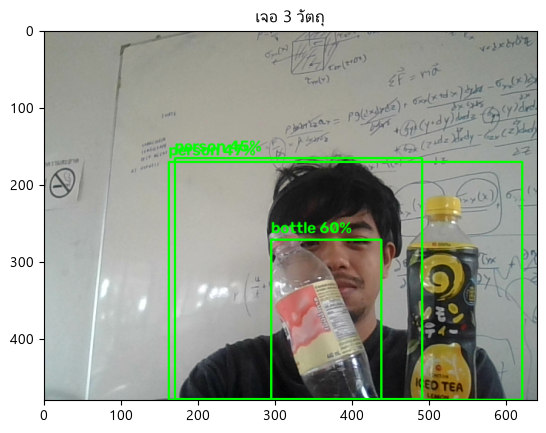

In [9]:
drawn_frame = frame.copy()
for box in results[0].boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])       # แปลงจาก tensor เป็นจำนวนเต็ม
    label = model.names[int(box.cls)]
    conf = float(box.conf)
    cv2.rectangle(drawn_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(drawn_frame, f"{label} {conf:.0%}", (x1, max(20, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(drawn_frame, cv2.COLOR_BGR2RGB))
plt.title(f"เจอ {len(results[0].boxes)} วัตถุ")
plt.show()

## 4. 🎛️ ปรับ threshold ความมั่นใจ (โดยไม่ต้องรันโมเดลซ้ำ)

รันโมเดลครั้งเดียวที่ threshold ต่ำมาก (`conf=0.05`) เพื่อเก็บผู้สมัครทุกตัวไว้ก่อน
แล้วใช้แถบเลื่อนกรองทีหลัง — เร็วกว่าเรียกโมเดลใหม่ทุกครั้งที่เลื่อน

In [ ]:
from ipywidgets import interact, FloatSlider

results_all = model.predict(frame, conf=0.05, verbose=False)[0]

def filter_by_conf(threshold=0.4):
    img = frame.copy()
    count = 0
    for box in results_all.boxes:
        conf = float(box.conf)
        if conf < threshold:
            continue
        count += 1
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        label = model.names[int(box.cls)]
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, f"{label} {conf:.0%}", (x1, max(20, y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    plt.figure(figsize=(6, 5))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"threshold={threshold:.2f} → เจอ {count} วัตถุ")
    plt.show()


interact(filter_by_conf, threshold=FloatSlider(0.4, min=0.05, max=0.95, step=0.05));

interactive(children=(FloatSlider(value=0.4, description='threshold', max=0.95, min=0.05, step=0.05), Output()…

threshold ต่ำ = เจอเยอะแต่มีของหลอกปน (false positive) | threshold สูง = แม่นแต่บางทีพลาดของจริงไป (false negative)
— ต้องเลือกจุดกลางที่เหมาะกับงาน (โปรเจคนี้ใช้ `YOLO_CONF = 0.5` ใน `config.py` เป็นจุดเริ่มต้น)

## 5. ทำไมโปรเจคนี้ต้อง "เทรนโมเดลเอง" ทั้งที่มี YOLO สำเร็จรูปแล้ว?

ลองดูรายชื่อ 80 ชนิดที่โมเดลนี้รู้จัก (มาจากชุดข้อมูล COCO):

In [11]:
print(list(model.names.values()))

['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


สังเกต 2 เรื่องสำคัญ:

1. **"elephant" มีอยู่ในลิสต์จริง!** แต่โมเดลถูกเทรนจากภาพ**ช้างจริง**ในธรรมชาติ ไม่ใช่ตุ๊กตาช้างพลาสติก/ผ้า
   โอกาสที่มันจะจำตุ๊กตาช้างของเล่นได้แม่นจึงต่ำมาก (รูปทรง/พื้นผิวต่างจากช้างจริงเยอะ)
2. **"ไดโนเสาร์" กับ "คาปิบาร่า" ไม่มีอยู่ในลิสต์เลย** — โมเดลไม่เคยเห็นมาก่อน ต่อให้ถือมายืนตรงหน้ากล้องก็หาไม่เจอ

**สรุป:** อยากให้ระบบแยกตุ๊กตาทั้ง 3 ตัวได้แม่น ต้อง **fine-tune** (เทรนต่อยอด) จากรูปตุ๊กตาจริงเอง
ไม่ใช่ใช้โมเดลสำเร็จรูปตรงๆ — ขั้นตอนเต็มอยู่ใน `docs/คู่มือโค้ด-อ่านก่อน.md` หัวข้อ "เทรน YOLO"
(สรุปคร่าวๆ: ถ่ายรูปตุ๊กตาแต่ละตัว ~100-150 รูปหลายมุม/แสง → ตีกรอบ label → เทรนต่อจาก `yolov8n.pt` ไม่กี่สิบ epoch)

## 6. เทียบกับโค้ดจริงในโปรเจค

`src/detector.py` มีคลาส `YoloDetector` ที่ทำสิ่งเดียวกับบทนี้เป๊ะ (ย่อมาให้อ่านง่าย):

```python
class YoloDetector:
    def __init__(self):
        self.model = YOLO(config.YOLO_MODEL_PATH)   # models/best.pt (โมเดลที่เทรนเองแล้ว)

    def detect(self, frame_bgr, target):
        want = config.TARGETS[target]["yolo_class"]     # เลขคลาสของเป้าที่เลือกใน UI
        results = self.model.predict(frame_bgr, conf=config.YOLO_CONF, verbose=False)
        best = None
        for box in results[0].boxes:
            if int(box.cls) != want:      # สนใจแค่คลาสที่ผู้ใช้เลือก ตัวอื่นข้ามไป
                continue
            if best is None or float(box.conf) > best.conf:
                best = ...   # เก็บกล่องที่มั่นใจสุดของคลาสนั้น
        return best
```

และใน `config.py` มีสวิตช์เดียวสลับได้ทั้งโปรเจค: `DETECTOR = "hsv"` หรือ `"yolo"`

---
## ✅ สรุปบทนี้ — และสรุปทั้งคอร์ส

| เรื่อง | สรุปสั้นๆ |
|---|---|
| YOLO ต่างจาก HSV | เรียนรู้รูปทรง/ลวดลายจากตัวอย่างจริง ไม่ใช่ไล่สี |
| `model.predict(frame, conf=...)` | รันตรวจจับ, threshold คุมความมั่นใจ |
| `box.xyxy / box.cls / box.conf` | พิกัด / ชนิด / ความมั่นใจของแต่ละกล่อง |
| ทำไมต้องเทรนเอง | ตุ๊กตา 3 ตัวไม่ได้อยู่ใน COCO 80 คลาส (หรืออยู่แต่หน้าตาต่างจากของจริงมาก) |

### 🎉 เรียนจบคอร์สแล้ว! สรุปเส้นทางทั้งหมดที่เพิ่งเรียนมา

```
บทที่ 0: ตัวเลข → numpy array → ภาพ
บทที่ 1: กล้อง → ภาพจริงเป็น array, BGR vs RGB
บทที่ 2: แยกสีด้วย HSV → mask
บทที่ 3: mask → contour → ตำแหน่งวัตถุ → error → มุมหมุนป้อม
บทที่ 4: ขนาดวัตถุในภาพ → ระยะจริง (calibrate ด้วยสามเหลี่ยมคล้าย)
บทที่ 5: (ทางเลือก) YOLO แทน HSV เมื่อสีไม่พอแยกวัตถุ
```

นี่คือ**ทุกส่วนของฝั่ง vision** ในโปรเจค Copper Dome ครบแล้ว — ที่เหลือคือประกอบเข้ากับฮาร์ดแวร์จริง (Arduino/servo/มอเตอร์)

➡️ **ก้าวต่อไป:** เปิด `START-HERE.md` แล้วไปที่ STEP 2 (ลองระบบเต็มแบบจำลอง `src/main.py --sim`) จากนั้น STEP 3 เมื่อได้อุปกรณ์จริง